In [20]:
# Peptide areas of all peptides assigned to a protein (histone), normalised on all proteins in the sample, averaged between 2 replicates
# Log2FC (fold change of peptide areas) vs Basiline (average abundance)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib as mpl
from adjustText import adjust_text
from matplotlib.ticker import FuncFormatter, FixedLocator


In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # TrueType
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['font.size'] = 16 


In [3]:
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, FixedLocator

In [4]:
# import the resulting excel table
Histone_mass_spec = pd.read_excel('/users/uladzis.khauratovich/user_uladzis_khauratovich/Khauratovich_Goloborodko_IMBA_ID2045_20250423_E4_insol_Urea_ArgC_2x2runs_mouse_histones_Top100_quanOnAll_v2.xlsm', sheet_name="Main", skiprows=2)


In [5]:
Histone_mass_spec = Histone_mass_spec[['Histones', 'Genes [v1]', 'Quantified Peptides', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_control_rep1', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_control_rep2', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_sample_Chd1KO_rep1', '20250423_E4_NEO8_Khauratovich_Goloborodko_IMBA_ID2045_insol_dig_Urea_DTT_ArgC_20per_sample_Chd1KO_rep2', 'SumPSMs', 'log2(Fold change (imputed))']]
Histone_mass_spec = Histone_mass_spec.iloc[2:].reset_index(drop=True)

In [6]:
Histone_mass_spec.columns = ['Histone_tick', 'Gene', 'Peptides', 'Ctr_1_area_norm', 'Ctr_2_area_norm', 'CHD1KO_1_area_norm', 'CHD1KO_2_area_norm', 'SumPSMs', 'Log2_FC']

Histone_mass_spec_f = Histone_mass_spec[Histone_mass_spec['Peptides'] > 2].copy()

Histone_mass_spec_f = Histone_mass_spec_f.astype({
    'Histone_tick': 'string',
    'Gene': 'string',
    'Peptides': 'float',
    'Ctr_1_area_norm': 'float',
    'Ctr_2_area_norm': 'float',
    'CHD1KO_1_area_norm': 'float',
    'CHD1KO_2_area_norm': 'float',
    'SumPSMs': 'float',
    'Log2_FC': 'float'
})

Histone_mass_spec_f['Histone_tick'] = (
    Histone_mass_spec_f['Histone_tick']
    .replace('ü', 'histone')
    .fillna('0')
)

Histone_mass_spec_f['Baseline'] = (
    Histone_mass_spec_f[['Ctr_1_area_norm', 'Ctr_2_area_norm', 'CHD1KO_1_area_norm', 'CHD1KO_2_area_norm']].mean(axis=1)
)

In [7]:
Histone_mass_spec_f

,Histone_tick,Gene,Peptides,Ctr_1_area_norm,Ctr_2_area_norm,CHD1KO_1_area_norm,CHD1KO_2_area_norm,SumPSMs,Log2_FC,Baseline
0,0,Tnp2,15.0,2.179301e+09,1.676163e+09,8.301325e+08,6.474760e+08,209.0,-1.382358,1.333268e+09
1,0,Psip1,34.0,1.556768e+09,1.502233e+09,1.564048e+09,1.626955e+09,679.0,0.060899,1.562501e+09
2,0,Ybx2,25.0,1.445913e+09,1.281710e+09,1.157345e+09,8.866847e+08,278.0,-0.426369,1.192913e+09
3,0,Cox6c,13.0,1.001894e+09,6.624878e+08,1.354730e+09,1.290149e+09,131.0,0.698423,1.077315e+09
4,0,Alyref,32.0,1.080822e+09,9.556467e+08,1.023039e+09,1.043652e+09,250.0,0.023912,1.025790e+09
...,...,...,...,...,...,...,...,...,...,...
121,histone,H2al1k,4.0,1.611597e+07,1.191952e+07,7.405779e+06,7.169098e+06,14.0,-0.927615,1.065259e+07
122,0,Prrc2a,20.0,7.206105e+06,8.493410e+06,5.702357e+06,4.246984e+06,66.0,-0.668783,6.412214e+06
123,0,Hdgfl2,15.0,8.112477e+06,8.283890e+06,6.734431e+06,8.196049e+06,36.0,-0.141983,7.831712e+06
124,0,HRNR,14.0,2.603643e+06,1.146947e+06,1.121823e+06,1.160596e+06,62.0,-0.598810,1.508253e+06


In [8]:
Histone_mass_spec_f['Names'] = Histone_mass_spec_f['Gene'].copy()

custom_gene_names = {
    "H4c1; H4c11; H4c12; H4c14; H4c16; H4c2; H4c3; H4c4; H4c6; H4c8; H4c9; Hist1h4m": "H4",
    "H3-3a; H3-3b": "H3-3",
    "H3f4": "H3t",
    "H1-6": "H1t",
    "H1-7": "H1T2",
    "H1-9": "H1FOO",
    "H1f10": "H1-10",
    "H2bu2": "TH2B"
}

Histone_mass_spec_f['Names'] = Histone_mass_spec_f['Names'].replace(custom_gene_names)

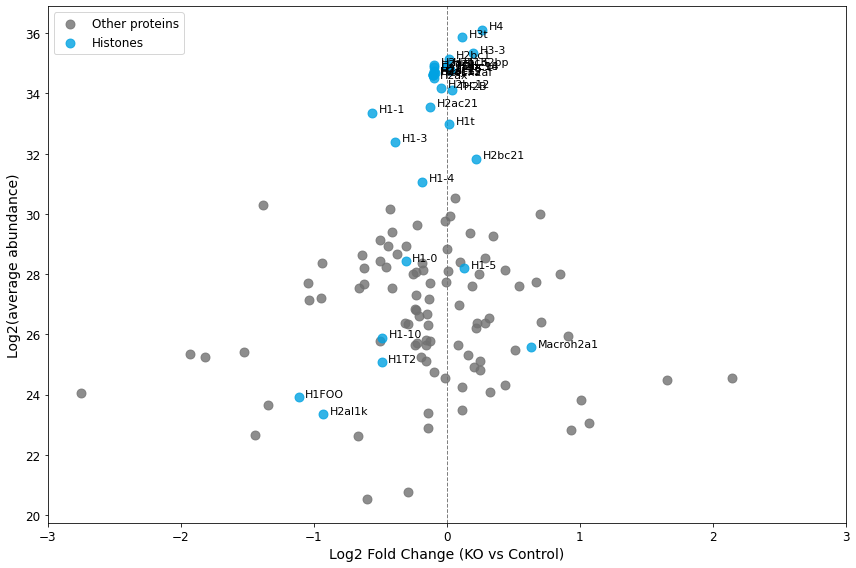

In [9]:
import matplotlib.pyplot as plt

# Separate histones and non-histones
histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] == 'histone']
non_histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] != 'histone']

plt.figure(figsize=(12, 8))

# Plot non-histones
plt.scatter(
    non_histones['Log2_FC'],
    np.log2(non_histones['Baseline']),
    color='#717171', #grey
    s=80,
    alpha=0.8,
    label='Other proteins'
)

# Highlight histones
plt.scatter(
    histones['Log2_FC'],
    np.log2(histones['Baseline']),
    color='#00a2e2', #blue
    s=80,
    alpha=0.8,
    label='Histones'
)

# x = 0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1, zorder=0)

plt.xlim(-3, 3)

plt.xlabel('Log2 Fold Change (KO vs Control)', fontsize=14)
plt.ylabel('Log2(average abundance)', fontsize=14)

# Ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Label only histones
for _, row in histones.iterrows():
    plt.text(
        row['Log2_FC'] + 0.05,        # x-offset
        np.log2(row['Baseline']) + 0.01,  # y-offset
        str(row['Names']),
        fontsize=11,
        color='black'
    )

plt.legend(fontsize=12, loc='upper left')

plt.tight_layout()
#plt.show()

# plt.savefig(
#     "Histones_mass_spec_basemean_allProtsNorm_logScale_labels.pdf",
#     format='pdf',
#     dpi=600,
#     bbox_inches="tight",
#     pad_inches=1,
#     transparent=False
# )

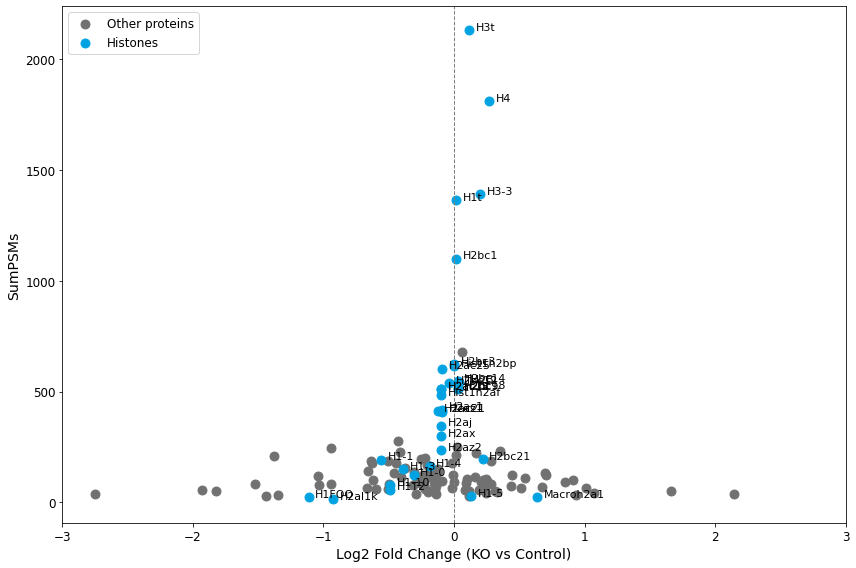

In [10]:
import matplotlib.pyplot as plt

# Separate histones and non-histones
histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] == 'histone']
non_histones = Histone_mass_spec_f[Histone_mass_spec_f['Histone_tick'] != 'histone']

# Set figure size and style
plt.figure(figsize=(12, 8))

# Plot non-histones in gray (bottom layer)
plt.scatter(
    non_histones['Log2_FC'],
    non_histones['SumPSMs'],
    color='#717171',
    s=80,
    label='Other proteins'
)

# Plot histones in blue (top layer)
plt.scatter(
    histones['Log2_FC'],
    histones['SumPSMs'],
    color='#00a2e2',
    s=80,
    label='Histones'
)

# Add vertical line at x = 0
plt.axvline(x=0, color='gray', linestyle='--', linewidth=1)

# Axis limits
plt.xlim(-3, 3)

# Labels and title
plt.xlabel('Log2 Fold Change (KO vs Control)', fontsize=14)
plt.ylabel('SumPSMs', fontsize=14)

# Ticks
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Label only histones
for _, row in histones.iterrows():
    plt.text(
        row['Log2_FC'] + 0.05,        # x-offset
        row['SumPSMs'] + 0.01,  # y-offset
        str(row['Names']),
        fontsize=11,
        color='black'
    )

# Legend
plt.legend(fontsize=12, loc='upper left')

# Layout
plt.tight_layout()
plt.show()

In [11]:
Histone_mass_spec = pd.read_excel('/users/uladzis.khauratovich/user_uladzis_khauratovich/Khauratovich_Goloborodko_IMBA_ID2045_20250423_E4_insol_Urea_ArgC_2x2runs_mouse_histones_Top100_quanOnAll_v2.xlsm', sheet_name="Peptide isoforms", skiprows=2)


In [12]:
# ! here normalised on all proteins abundance (Normlog2(Fold change).2), if want normilised on ribosomal protein abundance (Normlog2(Fold change).1)
Histone_mass_spec = Histone_mass_spec[['Master protein descriptions', 'Genes [v1]', 'Sequence', 'Modifications', '# PSMs', 'Sample areas', 'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Normlog2(Fold change).2']]
Histone_mass_spec.columns = ['Master_protein', 'Gene', 'Sequence', 'Modification', 'PSMs', 'ctr_1', 'ctr_2', 'chd1ko_1', 'chd1ko_2', 'nLog2_FC']
Histone_mass_spec = Histone_mass_spec[Histone_mass_spec['Master_protein'].str.contains('Histone', na=False)]


In [13]:
Histone_mass_spec['Modification'] = (
    Histone_mass_spec['Modification']
    .fillna('NoModif')
)

Histone_mass_spec['Baseline'] = (
    Histone_mass_spec[['ctr_1', 'ctr_2', 'chd1ko_1', 'chd1ko_2']].mean(axis=1)
)

In [14]:
Histone_mass_spec = Histone_mass_spec.dropna(subset=["nLog2_FC"])

In [15]:
Histone_mass_spec['Names'] = Histone_mass_spec['Gene'].copy()

custom_gene_names = {
    "H4c1; H4c11; H4c12; H4c14; H4c16; H4c2; H4c3; H4c4; H4c6; H4c8; H4c9; Hist1h4m": "H4",
    "H3-3a; H3-3b": "H3-3",
    "H3f4": "H3t",
    "H1-6": "H1t",
    "H1-7": "H1T2",
    "H1-9": "H1FOO",
    "H1f10": "H1-10",
    "H2bu2": "TH2B"
}

Histone_mass_spec['Names'] = Histone_mass_spec['Names'].replace(custom_gene_names)

In [18]:
groups = {
    "Acetyl":     (r"Acetyl",    r"Oxidation|Carbamyl|Methyl|Phospho"),
    "Methyl":     (r"Methyl",    r"Oxidation|Carbamyl|Dimethyl|Trimethyl|Acetyl|Phospho"),
    "Dimethyl":   (r"Dimethyl",  r"Oxidation|Carbamyl|Trimethyl|Acetyl|Phospho"),
    "Trimethyl":  (r"Trimethyl", r"Oxidation|Carbamyl|Dimethyl|Acetyl|Phospho"),
    "Phospho":    (r"Phospho",   r"Oxidation|Carbamyl|Methyl|Acetyl"),
    "Multiple":   (r"];",         r"Oxidation|Carbamyl"),
}

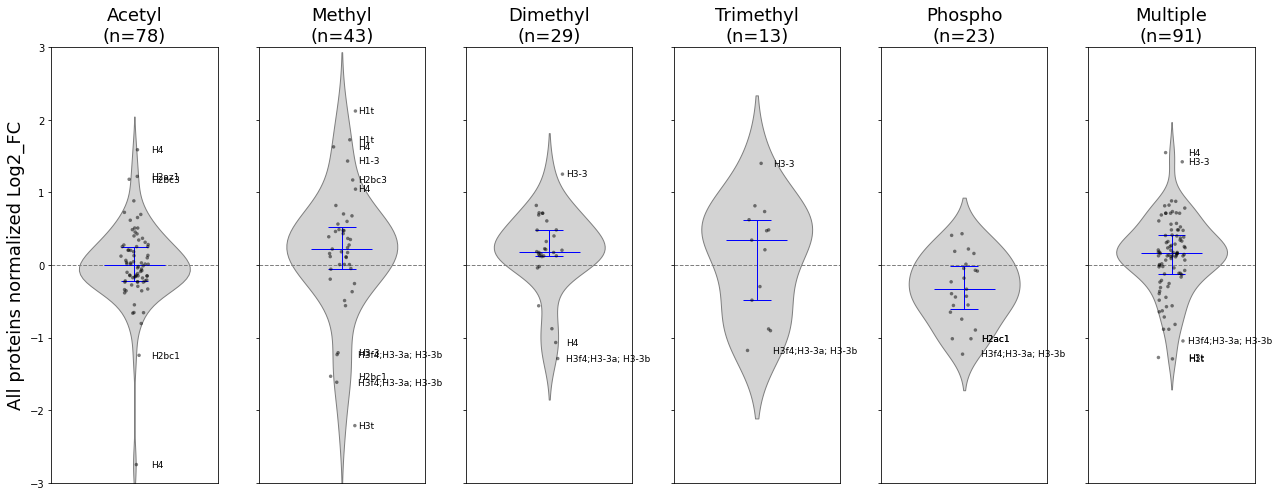

In [19]:
fig, axes = plt.subplots(1, 6, figsize=(18, 7), sharey=True)  # a bit wider

for ax, (label, (must_have, must_not)) in zip(axes, groups.items()):
    mask = (
        Histone_mass_spec["Modification"].str.contains(must_have, case=False, na=False) &
        ~Histone_mass_spec["Modification"].str.contains(must_not, case=False, na=False)
    )
    # keep Names so we can label
    sub = Histone_mass_spec.loc[mask, ["nLog2_FC", "Names"]].copy()
    sub["nLog2_FC"] = pd.to_numeric(sub["nLog2_FC"], errors="coerce")
    sub = sub.dropna(subset=["nLog2_FC"])

    sns.violinplot(y="nLog2_FC", data=sub, inner=None, color="lightgrey", linewidth=1, ax=ax)
    sns.stripplot(y="nLog2_FC", data=sub, color="black", alpha=0.5, jitter=True, size=3.5, ax=ax)

    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{label}\n(n={len(sub)})", fontsize=18)
    ax.set_xlabel("")
    ax.set_xticks([])

    # median & IQR guides
    vals = sub["nLog2_FC"]
    q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
    ax.hlines(med, -0.22, 0.22, colors="blue", linewidth=1)
    ax.vlines(0.0, q1, q3, colors="blue", linewidth=1)
    ax.hlines([q1, q3], -0.10, 0.10, colors="blue", linewidth=1)

    # give room for labels at left/right
    ax.set_xlim(-0.6, 0.6)

    # label points with |fc| > 1 using Names (right side of the dot)
    for _, row in sub.iterrows():
        fc = row["nLog2_FC"]
        if fc > 1 or fc < -1:
            name = str(row["Names"]) if pd.notnull(row["Names"]) else ""
            ax.text(0.12, fc, name, fontsize=9, va="center", ha="left", zorder=5, clip_on=False)

axes[0].set_ylabel("All proteins normalized Log2_FC", fontsize=18)
for ax in axes[1:]:
    ax.set_ylabel("")

plt.ylim(-3, 3)
plt.tight_layout()
plt.show()

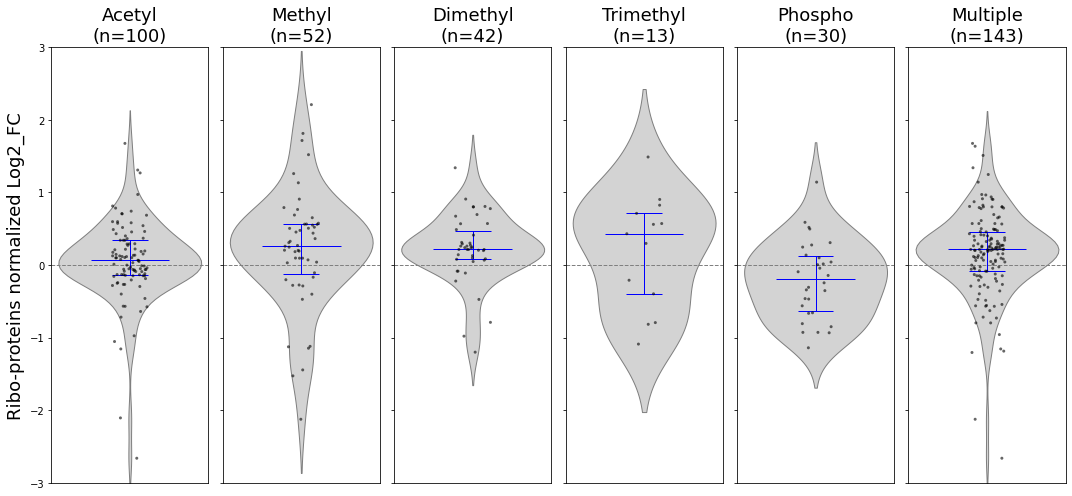

In [64]:
# ! here normalised on all proteins abundance (Normlog2(Fold change).2)
# if want normilised on ribosomal protein abundance (Normlog2(Fold change).1) change the initial df

fig, axes = plt.subplots(1, 6, figsize=(15,7), sharey=True)

for ax, (label, (must_have, must_not)) in zip(axes, groups.items()):
    mask = (
        Histone_mass_spec["Modification"].str.contains(must_have, case=False, na=False)
        & ~Histone_mass_spec["Modification"].str.contains(must_not, case=False, na=False)
    )
    sub = Histone_mass_spec.loc[mask, ["nLog2_FC"]].copy()
    sub["nLog2_FC"] = pd.to_numeric(sub["nLog2_FC"], errors="coerce")
    sub = sub.dropna()

    sns.violinplot(y="nLog2_FC", data=sub, inner=None, color="lightgrey", linewidth=1, ax=ax)
    sns.stripplot(y="nLog2_FC", data=sub, color="black", alpha=0.6, jitter=True, size=3, ax=ax)
    ax.axhline(0, color="grey", linestyle="--", linewidth=1)
    ax.set_title(f"{label}\n(n={len(sub)})", fontsize=18)
    ax.set_xlabel("")
    ax.set_xticks([])
    
    vals = sub["nLog2_FC"]
    q1, med, q3 = vals.quantile([0.25, 0.5, 0.75])
    ax.hlines(med, -0.22, 0.22, colors="blue", linewidth=1)          # median (horizontal)
    ax.vlines(0.0, q1, q3, colors="blue", linewidth=1)               # IQR spine (vertical)
    ax.hlines([q1, q3], -0.10, 0.10, colors="blue", linewidth=1)

axes[0].set_ylabel("Ribo-proteins normalized Log2_FC", fontsize = 18)
for ax in axes[1:]:
    ax.set_ylabel("")

plt.ylim(-3, 3)
plt.tight_layout()
plt.show()